# 模型批量验证对比 Notebook

本 Notebook 用于在 **train / valid / test** 三个数据集上系统性对比微调模型与原始模型的检测性能。

整体内容按照“先推理分析、后结果对比”的顺序组织：先完成模型加载、数据集准备、单/多GPU推理与指标汇总，再进入结果展示、可视化对比和差异分析。

多GPU模式默认启用 `rank0` 的 tqdm 总进度条，并通过 `tqdm.write(...)` 输出固定宽度的阶段摘要日志，避免进度条与状态打印相互覆盖。

## 评估维度

1. **数值量化指标**: IOU、精确率(Precision)、召回率(Recall)、F1分数、检测准确率
2. **跨数据集对比**: 在 train / valid / test 上分别评估，观察泛化能力
3. **可视化对比**: 指标雷达图、分组柱状图、差异热力图
4. **差异分析**: 自动识别关键差异点并生成简要分析

---


## 0. 环境配置


In [1]:
import json
import os
import re
import sys
import time
import warnings
from collections import Counter, defaultdict
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np

_nb_file = globals().get("__vsc_ipynb_file__", "")
_bootstrap_starts = [Path.cwd()] + ([Path(_nb_file).parent] if _nb_file else [])
for _start in _bootstrap_starts:
    for _candidate in [_start] + list(_start.parents):
        src_dir = _candidate / "src"
        if src_dir.exists() and (src_dir / "unsloth_finetune" / "__init__.py").exists():
            if str(src_dir) not in sys.path:
                sys.path.insert(0, str(src_dir))
            break

from unsloth_finetune.notebooking.vision_shared import configure_matplotlib_for_chinese, print_torch_runtime_info

warnings.filterwarnings("ignore")

try:
    from io import BytesIO

    import matplotlib.font_manager as fm
    import matplotlib.patches as mpatches
    import matplotlib.pyplot as plt
    import requests
    import torch
    from matplotlib.gridspec import GridSpec
    from PIL import Image, ImageDraw, ImageFont

    if hasattr(__builtins__, "__IPYTHON__"):
        from tqdm.notebook import tqdm
    else:
        from tqdm import tqdm

    configure_matplotlib_for_chinese(plt, fm, warn=True)

    print("依赖加载成功")
    print_torch_runtime_info(torch, "PyTorch版本")
except ImportError as e:
    print(f"缺少依赖: {e}")
    print("请安装: pip install torch pillow matplotlib requests numpy")
    sys.exit(1)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
依赖加载成功
PyTorch版本: 2.10.0+cu128
GPU: NVIDIA RTX 5880 Ada Generation
VRAM: 47.4 GB
CUDA版本: 12.8


## 1. 评估指标模块

包含 IOU 计算器（边界框重叠度）和检测指标计算器（精确率/召回率/F1等）。


In [2]:
from unsloth_finetune.notebooking.eval_shared import (
    DatasetLoader,
    IOUCalculator,
    MetricsCalculator,
    MetricsVisualizer,
    ResultManager,
    compute_diff_table,
    format_metrics_table,
    generate_analysis,
    load_multi_gpu_evaluation_outputs,
)
from unsloth_finetune.notebooking.vision_shared import ComparisonVisualizer, ModelLoader, ObjectDetector


## 2. 配置参数

修改以下配置单元格中的参数即可适配不同环境。所有路径基于 `PROJECT_ROOT` 自动推导。

**评估模式说明:**

| 模式        | 说明          | 适用场景           |
| ----------- | ------------- | ------------------ |
| `single`    | 单GPU推理评估 | 快速验证, 调试模式 |
| `multi_gpu` | 多GPU并行推理 | 大规模数据集评估   |

**跨Notebook参数关联:**

- `BASE_MODEL_PATH`: 与 **02-微调** 和 **03-推理** Notebook 中的基础模型路径保持一致
- `LORA_ADAPTER_PATH`: 由 **02-微调** Notebook 生成的 LoRA 适配器路径
- `DATA_DIR`: 由 **01-数据预处理** Notebook 生成的 JSONL 数据目录


In [3]:
from pathlib import Path
import sys

_nb_file = globals().get("__vsc_ipynb_file__", "")
_bootstrap_starts = [Path.cwd()] + ([Path(_nb_file).parent] if _nb_file else [])
for _start in _bootstrap_starts:
    for _candidate in [_start] + list(_start.parents):
        if (_candidate / "pyproject.toml").exists():
            if str(_candidate) not in sys.path:
                sys.path.insert(0, str(_candidate))
            break

from unsloth_finetune.notebooking.common import initialize_notebook_context

NOTEBOOK_CONTEXT = initialize_notebook_context(notebook_file=_nb_file, cwd=Path.cwd(), configure_unsloth_cache=True)
NOTEBOOK_DIR = NOTEBOOK_CONTEXT["NOTEBOOK_DIR"]
PROJECT_ROOT = NOTEBOOK_CONTEXT["PROJECT_ROOT"]
UNSLOTH_CACHE_DIR = NOTEBOOK_CONTEXT["UNSLOTH_CACHE_DIR"]
print(f"Unsloth compile cache: {UNSLOTH_CACHE_DIR}")

# ============================================================
# 加载模型配置
# ============================================================
# 使用配置管理系统，统一管理模型相关参数
# 切换模型只需更改配置名称，无需修改其他代码

from unsloth_finetune.notebooking.configs import load_model_config, list_available_configs

# 【配置选择】当前使用的模型配置
# 可用配置: gemma4_e4b, qwen3_5_4b, llama3_2_3b
# 切换模型: 将 MODEL_CONFIG_NAME 改为对应配置名称即可
MODEL_CONFIG_NAME = "gemma4_e4b"

config = load_model_config(MODEL_CONFIG_NAME)
print(f"已加载配置: {config.model.name} ({config.model.family})")
print(f"可用配置列表: {list_available_configs()}")

# ============================================================
# 评估模式选择
# ============================================================
# "single"       → 单GPU推理评估 + 结果展示/指标分析 (Section 7-8 + Section 10-13)
# "multi_gpu"    → 多GPU并行推理 + 结果展示/指标分析 (Section 8-13)
EVAL_MODE = "multi_gpu"

VALID_EVAL_MODES = {"single", "multi_gpu"}
if EVAL_MODE not in VALID_EVAL_MODES:
    raise ValueError(f"EVAL_MODE必须是{VALID_EVAL_MODES}之一, 当前: {EVAL_MODE}")

print(f"评估模式: {EVAL_MODE}")

# ---------- 模型路径配置 (从配置文件读取) ----------
# 基础模型路径由配置文件管理
BASE_MODEL_PATH = config.model.base_model_path or "unsloth/gemma-4-E4B-it-bnb-4bit"
# 如需临时覆盖，取消注释以下行
# BASE_MODEL_PATH = "/raid5/sh/model/unsloth/gemma-4-E4B-it-unsloth-bnb-4bit"
LORA_ADAPTER_PATH = str(PROJECT_ROOT / "models" / "finetuned" / "gemma4_e4b_lora" / "ddp_8gpu/20260526_084815")

# ---------- 数据集路径配置 ----------
# 由01-数据预处理Notebook生成的JSONL数据目录
DATA_DIR = str(PROJECT_ROOT / "data" / "processed" / "unsloth_training_data-wgang_40")
# 加载三个数据集
data_dir = Path(DATA_DIR)
split_files = {
    # "train": data_dir / "train.jsonl",
    # "valid": data_dir / "val.jsonl",
    "test": data_dir
    / "test.jsonl",
}


# ---------- 模型加载参数 (从配置文件读取) ----------
MAX_SEQ_LENGTH = config.model_loading.max_seq_length
LOAD_IN_4BIT = config.model_loading.load_in_4bit
print(f"模型参数: seq_len={MAX_SEQ_LENGTH}, 4bit={LOAD_IN_4BIT}")

# ---------- 推理模式配置 ----------
INFERENCE_MODE = "sequential"
INFERENCE_PARALLEL_MODE = "single_gpu" if EVAL_MODE == "single" else "multi_gpu"

# ---------- 多GPU并行推理配置 ----------
MULTI_GPU_ENABLED = EVAL_MODE == "multi_gpu"
MULTI_GPU_IDS = [0, 1, 2, 3, 4, 5, 6, 7]
MULTI_GPU_STRATEGY = "data_parallel"
MULTI_GPU_SCHEDULER_MODE = "dynamic_queue"
MULTI_GPU_LOAD_BALANCE = "round_robin"
MULTI_GPU_RESULT_DIR = str(PROJECT_ROOT / "results" / "multi_gpu_inference")
MULTI_GPU_LABELME_OUTPUT = True

# ---------- Multi-GPU launch configuration ----------
# Follow the training notebook pattern: notebook prepares config only,
# and the actual multi-GPU inference runs in a standalone torchrun script.
MULTI_GPU_EXECUTOR_BACKEND = "torchrun"  # torchrun | process | thread
MULTI_GPU_BATCH_SIZE = 4
MULTI_GPU_AUTO_RUN_TORCHRUN = True
MULTI_GPU_TORCHRUN_PORT = 29510
MULTI_GPU_TORCHRUN_SCRIPT_PATH = str(PROJECT_ROOT / "src" / "unsloth_finetune" / "training" / "distributed" / "distributed_inference.py")
MULTI_GPU_TORCHRUN_WORKDIR = str(PROJECT_ROOT)
MULTI_GPU_TORCHRUN_USE_BASH = os.name != "nt"  # legacy; get_ipython().system mode ignores this
MULTI_GPU_TORCHRUN_RAISE_ON_ERROR = True
MULTI_GPU_TORCHRUN_PROGRESS_RANKS = "0"
MULTI_GPU_PARALLEL_MODEL_LOADING = False  # legacy; torchrun mode ignores this
MULTI_GPU_MAX_CONCURRENT_MODEL_LOADS = 1  # legacy; torchrun mode ignores this
MULTI_GPU_MODEL_START_STAGGER_SECONDS = 0.0  # legacy; torchrun mode ignores this
MULTI_GPU_WRITE_LABELME_DURING_INFERENCE = False
MULTI_GPU_MODEL_SCHEDULE = "sequential_rounds"  # torchrun worker runs sequential rounds

# 旧版兼容参数
INFERENCE_GPU_IDS = MULTI_GPU_IDS
INFERENCE_MODELS_PER_GPU = 1
INFERENCE_GPU_GROUPS = [[g] for g in MULTI_GPU_IDS]
INFERENCE_DEVICE_MAP_STRATEGY = "cuda:0"

if INFERENCE_PARALLEL_MODE == "single_gpu":
    DEVICE_MAP = {"": INFERENCE_GPU_IDS[0]}
elif INFERENCE_PARALLEL_MODE == "device_map":
    DEVICE_MAP = INFERENCE_DEVICE_MAP_STRATEGY
else:
    DEVICE_MAP = {"": INFERENCE_GPU_IDS[0]}

# ---------- 推理参数 ----------
INFERENCE_MAX_NEW_TOKENS = 512
INFERENCE_TEMPERATURE = 0.7
INFERENCE_TOP_P = 0.9

# ---------- 评估参数 ----------
IOU_MATCH_THRESHOLD = 0.5
CONFIDENCE_THRESHOLDS = [0.5, 0.7, 0.85, 0.95]
MAX_EVAL_SAMPLES = None

# ---------- 可视化参数 ----------
CHART_DPI = 150
CHART_STYLE = "seaborn-v0_8-whitegrid"

# ---------- 结果持久化配置 ----------
INFERENCE_RESULT_DIR = str(PROJECT_ROOT / "results" / "comparison_cache")
INFERENCE_FORCE_RERUN = False

# 模式功能开关 (single / multi_gpu 均包含结果展示与指标分析)
ENABLE_SINGLE_GPU_INFERENCE = EVAL_MODE == "single"
ENABLE_MULTI_GPU_INFERENCE = EVAL_MODE == "multi_gpu"
ENABLE_METRICS_COMPARISON = EVAL_MODE in {"single", "multi_gpu"}
ENABLE_VISUALIZATION = EVAL_MODE in {"single", "multi_gpu"}

print(f"\n{'='*50}")
print(f"评估配置摘要")
print(f"{'='*50}")
print(f"单GPU推理: {'启用' if ENABLE_SINGLE_GPU_INFERENCE else '跳过'}")
print(f"多GPU推理: {'启用' if ENABLE_MULTI_GPU_INFERENCE else '跳过'}")
print(f"结果展示/指标分析: {'启用' if ENABLE_METRICS_COMPARISON else '跳过'}")
print(f"可视化: {'启用' if ENABLE_VISUALIZATION else '跳过'}")

print(f"\n项目根目录: {PROJECT_ROOT}")
print(f"基础模型: {BASE_MODEL_PATH}")
print(f"LoRA适配器: {LORA_ADAPTER_PATH}")
print(f"数据目录: {DATA_DIR}")
print(f"推理模式: {INFERENCE_MODE} ({INFERENCE_PARALLEL_MODE})")
if MULTI_GPU_ENABLED:
    print(f"多GPU并行: 启用, GPU IDs: {MULTI_GPU_IDS}")
    print(f"并行策略: {MULTI_GPU_STRATEGY}, 调度模式: {MULTI_GPU_SCHEDULER_MODE}, 静态分片: {MULTI_GPU_LOAD_BALANCE}")
    print(f"executor_backend={MULTI_GPU_EXECUTOR_BACKEND}, batch_size={MULTI_GPU_BATCH_SIZE}, progress_ranks={MULTI_GPU_TORCHRUN_PROGRESS_RANKS}")
    print("日志输出: rank0显示tqdm总进度条, 摘要日志通过tqdm.write按固定宽度对齐输出")
print(f"结果缓存目录: {INFERENCE_RESULT_DIR}")
# _MODIFIED_MODE_FLOW_V3

Unsloth compile cache: /raid5/sh/code/unsloth-finetune/notebooks/unsloth_compiled_cache
已加载配置: gemma4_e4b (gemma)
可用配置列表: ['base_config', 'gemma4_e4b_config', 'llama3_2_3b_config', 'qwen3_5_4b_config']
评估模式: multi_gpu
模型参数: seq_len=2048, 4bit=True

评估配置摘要
单GPU推理: 跳过
多GPU推理: 启用
结果展示/指标分析: 启用
可视化: 启用

项目根目录: /raid5/sh/code/unsloth-finetune
基础模型: /raid5/sh/model/unsloth/gemma-4-E4B-it-unsloth-bnb-4bit
LoRA适配器: /raid5/sh/code/unsloth-finetune/models/finetuned/gemma4_e4b_lora/ddp_8gpu/20260526_084815
数据目录: /raid5/sh/code/unsloth-finetune/data/processed/unsloth_training_data-wgang_40
推理模式: sequential (multi_gpu)
多GPU并行: 启用, GPU IDs: [0, 1, 2, 3, 4, 5, 6, 7]
并行策略: data_parallel, 调度模式: dynamic_queue, 静态分片: round_robin
executor_backend=torchrun, batch_size=4, progress_ranks=0
日志输出: rank0显示tqdm总进度条, 摘要日志通过tqdm.write按固定宽度对齐输出
结果缓存目录: /raid5/sh/code/unsloth-finetune/results/comparison_cache


## 3. 模型配置

所有模型路径参数已在上方 **2. 配置参数** 单元格中集中定义，`MODEL_CONFIG` 自动读取这些值。


In [4]:
MODEL_CONFIG = {
    "base_model": {
        "name": "原始模型",
        "base_model_path": BASE_MODEL_PATH,
        "max_seq_length": MAX_SEQ_LENGTH,
        "load_in_4bit": LOAD_IN_4BIT,
        "device_map": DEVICE_MAP,
    },
    "finetuned_model": {
        "name": "微调模型",
        "base_model_path": BASE_MODEL_PATH,
        "lora_adapter_path": LORA_ADAPTER_PATH,
        "max_seq_length": MAX_SEQ_LENGTH,
        "load_in_4bit": LOAD_IN_4BIT,
        "device_map": DEVICE_MAP,
    },
}

print("配置已加载")
print(f"  基础模型: {BASE_MODEL_PATH}")
print(f"  LoRA适配器: {LORA_ADAPTER_PATH}")
print(f"  数据目录: {DATA_DIR}")

配置已加载
  基础模型: /raid5/sh/model/unsloth/gemma-4-E4B-it-unsloth-bnb-4bit
  LoRA适配器: /raid5/sh/code/unsloth-finetune/models/finetuned/gemma4_e4b_lora/ddp_8gpu/20260526_084815
  数据目录: /raid5/sh/code/unsloth-finetune/data/processed/unsloth_training_data-wgang_40


## 4. 模型加载模块


## 5. 目标检测模块


## 6. 可视化模块

包含检测结果可视化对比器和指标可视化器（雷达图、柱状图等）。


## 7. 加载模型

根据推理模式配置, 支持两种加载策略:

- **顺序化模式** (`INFERENCE_MODE = "sequential"`): 同一时刻仅加载一个模型, 降低显存占用。模型在推理阶段逐个加载→推理→卸载, 结果持久化到磁盘支持缓存复用。
- **并行模式** (`INFERENCE_MODE = "parallel"`): 同时加载两个模型到显存, 保留原始行为, 适合显存充足的场景。

**流程控制说明:**

- 当 `EVAL_MODE = "single"` 时, 本节按配置准备单GPU推理
- 当 `EVAL_MODE = "multi_gpu"` 时, 此步骤跳过, 模型在 Section 9 的 `torchrun` worker 中加载


In [5]:
visualizer = ComparisonVisualizer()
metrics_visualizer = MetricsVisualizer()

if EVAL_MODE == "single":
    if INFERENCE_MODE == "sequential":
        print("=" * 60)
        print("单GPU顺序化推理模式")
        print("=" * 60)
        print(f"推理模式: {INFERENCE_MODE}")
        print(f"并行策略: {INFERENCE_PARALLEL_MODE}")
        print(f"GPU IDs: {INFERENCE_GPU_IDS}")
        print(f"DEVICE_MAP: {DEVICE_MAP}")
        print("模型将在推理阶段逐个加载, 不在此处预加载")
        model_loader_base = None
        model_loader_finetuned = None
        detector_base = None
        detector_finetuned = None
    elif INFERENCE_MODE == "parallel":
        print("=" * 60)
        print("单GPU并行推理模式 - 同时加载两个模型")
        print("=" * 60)
        model_loader_base = ModelLoader(MODEL_CONFIG["base_model"])
        model_loader_finetuned = ModelLoader(MODEL_CONFIG["finetuned_model"])

        print("\n" + "=" * 60)
        print("加载原始模型")
        print("=" * 60)
        success_base = model_loader_base.load_model()

        print("\n" + "=" * 60)
        print("加载微调模型")
        print("=" * 60)
        success_finetuned = model_loader_finetuned.load_model()

        if success_base and success_finetuned:
            print("\n所有模型加载成功!")
            detector_base = ObjectDetector(
                model_loader_base,
                temperature=INFERENCE_TEMPERATURE,
                top_p=INFERENCE_TOP_P,
            )
            detector_finetuned = ObjectDetector(
                model_loader_finetuned,
                temperature=INFERENCE_TEMPERATURE,
                top_p=INFERENCE_TOP_P,
            )
        else:
            raise RuntimeError("\n模型加载失败,请检查配置")
    else:
        raise ValueError(f"未知推理模式: {INFERENCE_MODE}")
elif EVAL_MODE == "multi_gpu":
    print("=" * 60)
    print("多GPU并行推理模式 - 模型在 Section 9 加载")
    print("=" * 60)
    print("此处跳过预加载, 等待多GPU推理引擎初始化")
    model_loader_base = None
    model_loader_finetuned = None
    detector_base = None
    detector_finetuned = None
else:
    raise ValueError(f"未知 EVAL_MODE: {EVAL_MODE}")


多GPU并行推理模式 - 模型在 Section 9 加载
此处跳过预加载, 等待多GPU推理引擎初始化


## 8. 数据集加载与解析

从 JSONL 文件加载 train/valid/test 数据集，解析每条记录的图片路径、查询文本和 ground truth 边界框。

**JSONL记录格式（对齐Unsloth官方标准）：**

```json
{"messages": [
    {"role": "user", "content": [{"type": "text", "text": "请分析这张图像..."}]},
    {"role": "assistant", "content": [{"type": "text", "text": "...检测结果..."}]}
], "images": ["path/to/img"], "metadata": {"image_width": ..., ...}}
```

**格式说明：**
- `messages` 中 `user` 的 `content` 仅包含 `{"type": "text"}` — 图片不在messages中
- 图片路径存储在独立的 `images` 字段
- 训练时由 `MultimodalDataset` 加载图片并嵌入 `messages` content

**Ground truth解析:** 从 assistant 消息中提取边界框坐标，格式取决于训练数据的 `output_format`：
- `box_2d_json`: JSON数组 `[{"box_2d": [x_min, y_min, x_max, y_max], "label": "...", "confidence": 1.0}]`
- `labelme_text`: 中文自由文本 `
类别: N个

详细边界框坐标...`


In [6]:
datasets = {}
for split_name, filepath in split_files.items():
    if filepath.exists():
        records = DatasetLoader.load_jsonl(str(filepath))
        datasets[split_name] = records
        print(f"{split_name} 数据集: {len(records)} 条记录 ({filepath})")
    else:
        print(f"警告: {split_name} 数据文件不存在: {filepath}")
        datasets[split_name] = []

total_records = sum(len(r) for r in datasets.values())
print(f"\n共加载 {total_records} 条记录")
if total_records == 0:
    print("错误: 未加载任何数据, 请检查 DATA_DIR 配置")


test 数据集: 84 条记录 (/raid5/sh/code/unsloth-finetune/data/processed/unsloth_training_data-wgang_40/test.jsonl)

共加载 84 条记录


In [7]:
MODIFIED_FLAG_MARKER = "SEQ_PARALLEL_V2_LOADED"

result_manager = ResultManager(INFERENCE_RESULT_DIR)
print(f"ResultManager已初始化, 缓存目录: {INFERENCE_RESULT_DIR}")


ResultManager已初始化, 缓存目录: /raid5/sh/code/unsloth-finetune/results/comparison_cache


## 9. 多GPU分布式推理

当前 Notebook 推荐使用 `torchrun + distributed_inference.py` 的数据并行方案。该节位于所有结果对比板块之前, 先完成分布式推理与结果落盘, 再进入统一的指标汇总与展示分析流程。

| 方案 | 适用场景 | 优势 | 说明 |
| ---- | -------- | ---- | ---- |
| `torchrun` 数据并行 | 多GPU, 每GPU一个模型实例 | 稳定可靠, 可分片处理大规模评估数据 | Notebook 负责生成命令并在完成后回收结果做展示/分析 |

> **流程控制说明:**
>
> - 当 `EVAL_MODE = "single"` 时, 此步骤跳过
> - 当 `EVAL_MODE = "multi_gpu"` 时, 启用多GPU推理, 完成后继续执行 Section 10-13 的批量评估、结果展示与指标分析
> - `torchrun` 模式会先展示启动命令、关键参数和执行方式, 再按配置决定是否在 Notebook 内直接启动
> - 如果 Notebook 内执行受限, 可直接复制同一条命令到终端运行


In [8]:
import shlex
from typing import Any


class DistributedInferenceConfig:
    """Generate a torchrun-based multi-GPU inference launch config."""

    VALID_MODES = ("single_gpu", "ddp", "ddp_2x", "device_map", "multi_gpu")

    def __init__(
        self,
        mode: str,
        gpu_ids: list,
        models_per_gpu: int = 1,
        gpu_groups: list = None,
        device_map_strategy: str = "balanced",
        model_configs: dict = None,
        result_dir: str = None,
        data_dir: str = None,
        split_files: dict = None,
        iou_threshold: float = 0.5,
        max_eval_samples: int = None,
        worker_script_path: str = None,
        torchrun_port: int = 29510,
        batch_size: int = 4,
        max_new_tokens: int = 512,
        temperature: float = 0.7,
        top_p: float = 0.9,
        export_labelme: bool = False,
        scheduler_mode: str = "dynamic_queue",
        partition_strategy: str = "round_robin",
    ):
        if mode not in self.VALID_MODES:
            raise ValueError(f"无效模式: {mode}, 有效值: {self.VALID_MODES}")
        self.mode = mode
        self.gpu_ids = gpu_ids
        self.models_per_gpu = models_per_gpu
        self.gpu_groups = gpu_groups or [[g] for g in gpu_ids]
        self.device_map_strategy = device_map_strategy
        self.model_configs = model_configs or {}
        self.result_dir = result_dir or "./results/distributed_cache"
        self.data_dir = data_dir or "./data/processed"
        self.split_files = split_files or {"test": "test.jsonl"}
        self.iou_threshold = iou_threshold
        self.max_eval_samples = max_eval_samples
        self.worker_script_path = worker_script_path or "scripts/distributed_inference.py"
        self.torchrun_port = int(torchrun_port)
        self.batch_size = int(batch_size)
        self.max_new_tokens = int(max_new_tokens)
        self.temperature = float(temperature)
        self.top_p = float(top_p)
        self.export_labelme = bool(export_labelme)
        self.scheduler_mode = str(scheduler_mode)
        self.partition_strategy = str(partition_strategy)

    def _apply_defaults(self) -> dict:
        n_gpus = len(self.gpu_ids)
        if self.mode in ("ddp", "multi_gpu"):
            self.models_per_gpu = 1
            self.gpu_groups = [[g] for g in self.gpu_ids]
        elif self.mode == "ddp_2x":
            self.models_per_gpu = 2
            n_groups = max(1, n_gpus // self.models_per_gpu)
            self.gpu_groups = [self.gpu_ids[i * self.models_per_gpu : (i + 1) * self.models_per_gpu] for i in range(n_groups)]
        return {"n_gpus": n_gpus, "n_groups": len(self.gpu_groups)}

    def ensure_worker_script(self) -> Path:
        path = Path(self.worker_script_path)
        if not path.exists():
            raise FileNotFoundError(f"推理脚本不存在: {path}")
        return path

    def _quote(self, value: Any) -> str:
        return shlex.quote(str(value))

    def generate_torchrun_command(self) -> str:
        info = self._apply_defaults()

        if self.mode not in ("multi_gpu", "ddp"):
            return "echo '当前模式不使用 torchrun 多GPU推理'"

        script_path = self.ensure_worker_script()
        test_path = self.split_files.get("test")
        if not test_path:
            raise ValueError("未找到 test 数据文件路径")

        base_config = self.model_configs.get("base_model", {})
        finetuned_config = self.model_configs.get("finetuned_model", {})

        cmd_parts = [
            "torchrun",
            f"--nproc_per_node={info['n_groups']}",
            "--rdzv_backend=c10d",
            f"--rdzv_endpoint=localhost:{self.torchrun_port}",
            self._quote(script_path),
            f"--gpu_ids {','.join(str(g) for g in self.gpu_ids)}",
            f"--base_model_path {self._quote(base_config['base_model_path'])}",
            f"--data_path {self._quote(test_path)}",
            f"--result_dir {self._quote(self.result_dir)}",
            f"--max_seq_length {int(base_config['max_seq_length'])}",
            f"--batch_size {self.batch_size}",
            f"--iou_threshold {self.iou_threshold}",
            f"--max_new_tokens {self.max_new_tokens}",
            f"--temperature {self.temperature}",
            f"--top_p {self.top_p}",
            f"--scheduler_mode {self._quote(self.scheduler_mode)}",
            f"--partition_strategy {self._quote(self.partition_strategy)}",
        ]

        if base_config.get("load_in_4bit"):
            cmd_parts.append("--load_in_4bit")

        lora_path = finetuned_config.get("lora_adapter_path")
        if lora_path:
            cmd_parts.append(f"--lora_adapter_path {self._quote(lora_path)}")

        if self.max_eval_samples:
            cmd_parts.append(f"--max_eval_samples {int(self.max_eval_samples)}")

        if self.export_labelme:
            cmd_parts.append("--export_labelme")

        base_cmd = " ".join(cmd_parts)
        gpu_csv = ",".join(str(g) for g in self.gpu_ids)
        if os.name == "nt":
            return f'set "CUDA_VISIBLE_DEVICES={gpu_csv}" && {base_cmd}'
        return f"CUDA_VISIBLE_DEVICES={gpu_csv} {base_cmd}"

    def format_command_preview(self, command: str) -> str:
        """Render a wrapped torchrun command for notebook display."""
        try:
            parts = shlex.split(command)
        except ValueError:
            return command

        if not parts:
            return command

        if len(parts) == 1:
            return parts[0]

        lines = []
        for index, part in enumerate(parts):
            suffix = " \\" if index < len(parts) - 1 else ""
            if index == 0:
                lines.append(f"{part}{suffix}")
            else:
                lines.append(f"  {part}{suffix}")
        return "\n".join(lines)

    def print_summary(self):
        info = self._apply_defaults()
        test_path = self.split_files.get("test")
        print("=" * 72)
        print("多GPU 分布式推理摘要")
        print("=" * 72)
        print(f"并行模式: {self.mode}")
        print(f"GPU IDs: {self.gpu_ids}")
        print(f"GPU分组: {self.gpu_groups}")
        print(f"torchrun进程数: {info['n_groups']}")
        print(f"worker脚本: {self.worker_script_path}")
        print(f"工作目录: {MULTI_GPU_TORCHRUN_WORKDIR}")
        print(f"rdzv端口: {self.torchrun_port}")
        print(f"测试集: {test_path}")
        print(f"结果目录: {self.result_dir}")
        print(f"batch_size: {self.batch_size}")
        print(f"调度模式: {self.scheduler_mode}")
        print(f"静态分片策略: {self.partition_strategy}")
        print(f"LabelMe导出: {'是' if self.export_labelme else '否'}")
        print(f"自动执行: {'是' if MULTI_GPU_AUTO_RUN_TORCHRUN else '否'}")
        print("=" * 72)


def build_torchrun_env() -> dict:
    env = os.environ.copy()
    pythonpath_entries = [str(PROJECT_ROOT)]
    if env.get("PYTHONPATH"):
        pythonpath_entries.append(env["PYTHONPATH"])
    env["PYTHONPATH"] = os.pathsep.join(pythonpath_entries)
    env.setdefault("GEMMA4_NOTEBOOK_DIR", str(NOTEBOOK_DIR))
    env.setdefault("GEMMA4_LIVE_TQDM_RANKS", MULTI_GPU_TORCHRUN_PROGRESS_RANKS)
    notebook_file = NOTEBOOK_CONTEXT.get("NOTEBOOK_FILE", "")
    if notebook_file:
        env["GEMMA4_NOTEBOOK_FILE"] = notebook_file
    return env


def run_torchrun_in_notebook(ddp_cmd: str, workdir: str, raise_on_error: bool = True) -> int:
    """Run torchrun via get_ipython().system so Notebook preserves terminal-style progress output better."""
    workdir_path = Path(workdir)
    if not workdir_path.exists():
        raise FileNotFoundError(f"工作目录不存在: {workdir_path}")

    env = build_torchrun_env()
    print("\n开始通过 get_ipython().system(...) 执行 torchrun ...")
    print(f"工作目录: {workdir_path}")
    print(f"执行命令: {ddp_cmd}")
    print(f"PYTHONPATH已注入项目根: {PROJECT_ROOT}")
    print(f"日志策略: live_tqdm={MULTI_GPU_TORCHRUN_PROGRESS_RANKS}, rank0显示tqdm总进度条, worker侧摘要日志通过tqdm.write输出")
    print("-" * 72)

    tracked_keys = [
        "PYTHONPATH",
        "GEMMA4_NOTEBOOK_DIR",
        "GEMMA4_NOTEBOOK_FILE",
        "GEMMA4_UNSLOTH_COMPILE_CACHE_DIR",
        "UNSLOTH_COMPILE_LOCATION",
    ]
    old_values = {key: os.environ.get(key) for key in tracked_keys}
    old_cwd = Path.cwd()

    try:
        os.chdir(workdir_path)
        for key, value in env.items():
            if key in tracked_keys and value:
                os.environ[key] = value

        return_code = get_ipython().system(ddp_cmd)
    finally:
        os.chdir(old_cwd)
        for key, old_value in old_values.items():
            if old_value is None:
                os.environ.pop(key, None)
            else:
                os.environ[key] = old_value

    return_code = int(return_code or 0)
    print("-" * 72)
    print(f"torchrun 已结束, return code = {return_code}")
    if return_code != 0 and raise_on_error:
        raise RuntimeError(f"torchrun 执行失败, return code = {return_code}")
    return return_code


if ENABLE_MULTI_GPU_INFERENCE:
    print("=" * 60)
    print("启用多GPU分布式推理")
    print("=" * 60)

    dist_config = DistributedInferenceConfig(
        mode=INFERENCE_PARALLEL_MODE,
        gpu_ids=INFERENCE_GPU_IDS,
        models_per_gpu=INFERENCE_MODELS_PER_GPU,
        gpu_groups=INFERENCE_GPU_GROUPS,
        device_map_strategy=INFERENCE_DEVICE_MAP_STRATEGY,
        model_configs=MODEL_CONFIG,
        result_dir=MULTI_GPU_RESULT_DIR,
        data_dir=DATA_DIR,
        split_files={k: str(v) for k, v in split_files.items()},
        iou_threshold=IOU_MATCH_THRESHOLD,
        max_eval_samples=MAX_EVAL_SAMPLES,
        worker_script_path=MULTI_GPU_TORCHRUN_SCRIPT_PATH,
        torchrun_port=MULTI_GPU_TORCHRUN_PORT,
        batch_size=MULTI_GPU_BATCH_SIZE,
        max_new_tokens=INFERENCE_MAX_NEW_TOKENS,
        temperature=INFERENCE_TEMPERATURE,
        top_p=INFERENCE_TOP_P,
        export_labelme=MULTI_GPU_LABELME_OUTPUT,
        scheduler_mode=MULTI_GPU_SCHEDULER_MODE,
        partition_strategy=MULTI_GPU_LOAD_BALANCE,
    )

    worker_script = dist_config.ensure_worker_script()
    ddp_cmd = dist_config.generate_torchrun_command()
    dist_config.print_summary()

    print("\ntorchrun 启动命令:")
    print("-" * 72)
    print(dist_config.format_command_preview(ddp_cmd))
    print("-" * 72)
    print(f"推理脚本: {worker_script}")
    print("提示: 如 Notebook 内执行受限, 可复制上述命令到终端运行")

    if MULTI_GPU_AUTO_RUN_TORCHRUN:
        run_torchrun_in_notebook(
            ddp_cmd,
            workdir=MULTI_GPU_TORCHRUN_WORKDIR,
            raise_on_error=MULTI_GPU_TORCHRUN_RAISE_ON_ERROR,
        )
    else:
        print("提示: 如需在当前 Notebook 运行, 可调用 run_torchrun_in_notebook(...)")

else:
    print("跳过多GPU分布式推理")
    print(f"当前 EVAL_MODE={EVAL_MODE}, ENABLE_MULTI_GPU_INFERENCE={ENABLE_MULTI_GPU_INFERENCE}")

启用多GPU分布式推理
多GPU 分布式推理摘要
并行模式: multi_gpu
GPU IDs: [0, 1, 2, 3, 4, 5, 6, 7]
GPU分组: [[0], [1], [2], [3], [4], [5], [6], [7]]
torchrun进程数: 8
worker脚本: /raid5/sh/code/unsloth-finetune/src/unsloth_finetune/training/distributed/distributed_inference.py
工作目录: /raid5/sh/code/unsloth-finetune
rdzv端口: 29510
测试集: /raid5/sh/code/unsloth-finetune/data/processed/unsloth_training_data-wgang_40/test.jsonl
结果目录: /raid5/sh/code/unsloth-finetune/results/multi_gpu_inference
batch_size: 4
调度模式: dynamic_queue
静态分片策略: round_robin
LabelMe导出: 是
自动执行: 是

torchrun 启动命令:
------------------------------------------------------------------------
CUDA_VISIBLE_DEVICES=0,1,2,3,4,5,6,7 \
  torchrun \
  --nproc_per_node=8 \
  --rdzv_backend=c10d \
  --rdzv_endpoint=localhost:29510 \
  /raid5/sh/code/unsloth-finetune/src/unsloth_finetune/training/distributed/distributed_inference.py \
  --gpu_ids \
  0,1,2,3,4,5,6,7 \
  --base_model_path \
  /raid5/sh/model/unsloth/gemma-4-E4B-it-unsloth-bnb-4bit \
  --data_path \
  /raid

## 10. 批量推理与指标计算

支持两种评估器: 单GPU 模式直接执行推理, 多GPU 模式则在本节统一回收 Section 9 产出的结果, 生成一致的 `all_results / all_metrics` 结构, 为后续结果对比做好准备。

- **SequentialEvaluator**: 顺序化推理评估器, 同一时刻仅加载一个模型。Phase1先加载微调模型推理并保存结果, 卸载后Phase2加载基础模型推理。结果持久化到磁盘, 支持缓存复用。
- **BatchEvaluator**: 并行评估器, 同时使用两个已加载模型推理, 保留原始行为。

根据 `INFERENCE_MODE` 配置自动选择评估器。


In [9]:
# 评估执行代码
if EVAL_MODE == "single":
    if INFERENCE_MODE == "sequential":
        print("=" * 60)
        print("使用 SequentialEvaluator (顺序化推理)")
        print("=" * 60)
        seq_evaluator = SequentialEvaluator(IOU_MATCH_THRESHOLD)
        all_results, all_metrics = seq_evaluator.evaluate_all(datasets, max_samples=MAX_EVAL_SAMPLES)
    elif INFERENCE_MODE == "parallel":
        print("=" * 60)
        print("使用 BatchEvaluator (并行推理)")
        print("=" * 60)
        evaluator = BatchEvaluator(detector_base, detector_finetuned, IOU_MATCH_THRESHOLD)
        all_results = {}
        all_metrics = {}
        for split_name, records in datasets.items():
            if not records:
                print(f"跳过空数据集: {split_name}")
                continue
            sample_results, aggregated = evaluator.evaluate_dataset(records, split_name, max_samples=MAX_EVAL_SAMPLES)
            all_results[split_name] = sample_results
            all_metrics[split_name] = aggregated
    else:
        raise ValueError(f"未知推理模式: {INFERENCE_MODE}")

    print("\n" + "=" * 60)
    print("单GPU评估完成!")
    print("=" * 60)
elif EVAL_MODE == "multi_gpu":
    print("=" * 60)
    print("多GPU并行推理模式 - 从 Section 9 结果恢复评估数据")
    print("=" * 60)
    all_results, all_metrics = load_multi_gpu_evaluation_outputs(
        datasets,
        result_dir=MULTI_GPU_RESULT_DIR,
        split_names=split_files.keys(),
        max_samples=MAX_EVAL_SAMPLES,
    )

    print("\n" + "=" * 60)
    print("多GPU评估结果已接入展示/指标分析流程!")
    print("=" * 60)
else:
    raise ValueError(f"未知 EVAL_MODE: {EVAL_MODE}")


多GPU并行推理模式 - 从 Section 9 结果恢复评估数据

多GPU评估结果已接入展示/指标分析流程!


## 11. 结果展示

以表格形式展示两个模型在各数据集上的关键指标对比。


In [10]:
if all_metrics and ENABLE_METRICS_COMPARISON:
    print("=" * 70)
    print("评估结果汇总")
    print("=" * 70)
    print(format_metrics_table(all_metrics))
    print(compute_diff_table(all_metrics))
elif not all_metrics:
    print("暂无评估结果, 请先运行批量评估")
else:
    print(f"当前 EVAL_MODE={EVAL_MODE}, 跳过结果展示 (ENABLE_METRICS_COMPARISON={ENABLE_METRICS_COMPARISON})")


评估结果汇总
数据集   | 模型     | 精确率     | 召回率     | F1       | 匹配IOU    | 成功率     | 样本数  
--------------------------------------------------------------------------
test     | 原始       | 0.536    | 1.000    | 0.536    | 0.000    | 0.536    | 84    
test     | 微调       | 0.512    | 1.000    | 0.512    | 0.000    | 0.512    | 84    
--------------------------------------------------------------------------

微调模型改进幅度 (微调 - 原始):
-------------------------------------------------------------------------
数据集      | 精确率差       | 召回率差       | F1差        | IOU差       | 成功率差      
-------------------------------------------------------------------------
test     |   -0.024  |   +0.000  |   -0.024  |   +0.000  |   -0.024
-------------------------------------------------------------------------


## 12. 可视化对比

生成多维可视化图表，直观展示两个模型在各数据集上的性能差异。

**图表类型:**

- 分组柱状图: 每个数据集上两个模型的各项指标并列对比
- 雷达图: 多维指标同时对比, 一眼看出模型优劣
- 热力图: 微调改进幅度, 绿色=提升, 红色=退化
- IOU分布箱线图: 匹配IOU的分布特征


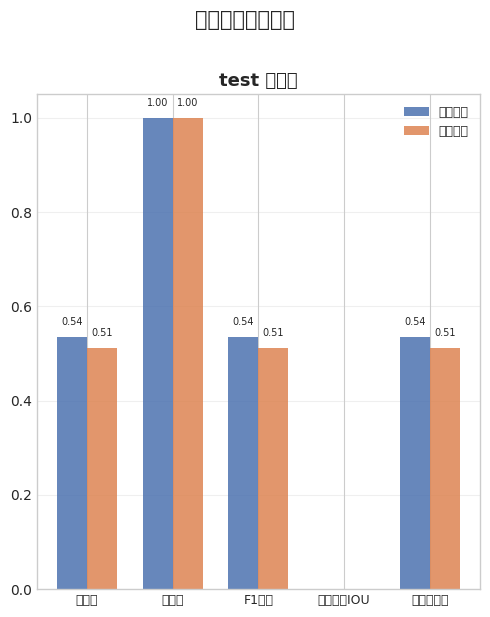

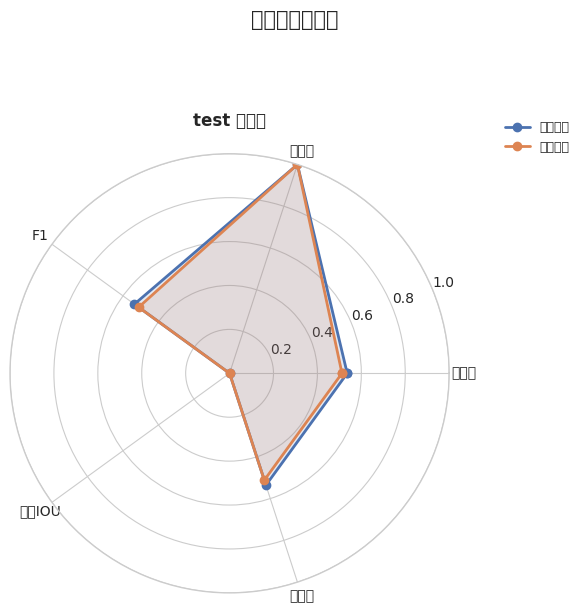

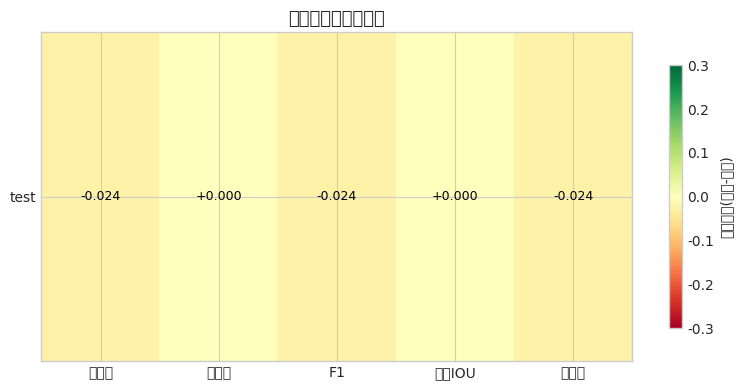

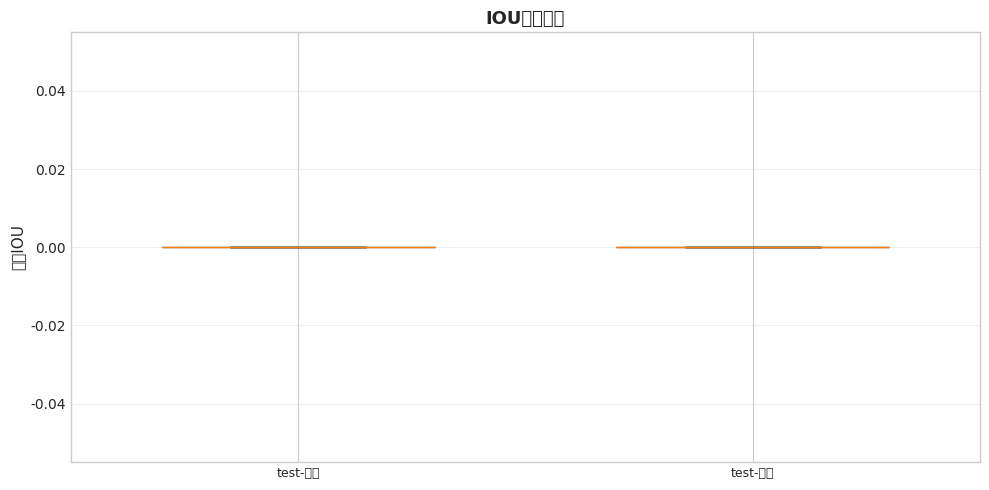

In [11]:
if all_metrics and ENABLE_VISUALIZATION:
    try:
        plt.style.use(CHART_STYLE)
    except Exception:
        pass

    metrics_visualizer.plot_metrics_bar_chart(plt, all_metrics, "模型性能分组对比")
    metrics_visualizer.plot_radar_chart(plt, all_metrics, "模型性能雷达图")
    metrics_visualizer.plot_diff_heatmap(plt, all_metrics)

    if all_results:
        metrics_visualizer.plot_iou_distribution(plt, all_results)
elif not all_metrics:
    print("暂无评估结果, 请先运行批量评估")
else:
    print(f"当前 EVAL_MODE={EVAL_MODE}, 跳过可视化 (ENABLE_VISUALIZATION={ENABLE_VISUALIZATION})")

## 13. 差异分析与总结

自动分析微调模型的关键改进点和潜在退化，生成结构化分析报告。


In [12]:
if all_metrics and ENABLE_METRICS_COMPARISON:
    analysis_report = generate_analysis(all_metrics, IOU_MATCH_THRESHOLD)
    print(analysis_report)
elif not all_metrics:
    print("暂无评估结果, 无法生成分析报告")
else:
    print(f"当前 EVAL_MODE={EVAL_MODE}, 跳过差异分析 (ENABLE_METRICS_COMPARISON={ENABLE_METRICS_COMPARISON})")


微调效果差异分析报告

生成时间: 2026-05-26 09:21:08
IOU匹配阈值: 0.5

一、总体改进分析
----------------------------------------

  [test 数据集]
    - 精确率: 0.536 -> 0.512 (退化 -0.024)
    = 召回率: 1.000 -> 1.000 (持平)
    - F1分数: 0.536 -> 0.512 (退化 -0.024)
    = 匹配IOU: 0.000 -> 0.000 (持平)
    - 检测成功率: 0.536 -> 0.512 (退化 -0.024)


二、关键发现
----------------------------------------

  需关注退化:
    - test数据集的精确率: 退化-0.024
    - test数据集的F1分数: 退化-0.024
    - test数据集的检测成功率: 退化-0.024


三、泛化能力分析
----------------------------------------


四、后续优化建议
----------------------------------------
  - 关注退化指标, 考虑调整训练数据分布或LoRA参数
  - 增加IOU阈值(0.5->0.7)可更严格评估定位精度
  - 可按类别分别统计指标, 找出薄弱类别针对性优化


---

## Notebook 完成总结

本 Notebook 按照“先推理分析、后结果对比”的顺序组织内容, 并实现了以下功能:

1. **数据集加载**: 从 JSONL 格式加载 train/valid/test 三个数据集
2. **Ground Truth 解析**: 从训练数据的 assistant 消息中提取边界框坐标
3. **单GPU评估**: 支持 SequentialEvaluator (顺序加载降低显存) 和 BatchEvaluator (并行推理)
4. **多GPU评估**: 通过 `torchrun` 调用 `distributed_inference.py` 执行数据并行推理
5. **结果持久化**: ResultManager 支持单GPU缓存复用, 多GPU结果目录可回收加载
6. **指标计算**: 精确率、召回率、F1、匹配IOU、检测成功率
7. **结果展示**: 文本表格 + 改进幅度表格
8. **可视化对比**: 分组柱状图、雷达图、热力图、IOU分布箱线图
9. **差异分析**: 自动识别关键改进点和退化风险

### 流程控制机制

10. **EVAL_MODE 模式选择**:
    | 模式 | 说明 | 执行流程 |
    |------|------|----------|
    | `single` | 单GPU推理评估 | Section 7-8 + Section 10-13 |
    | `multi_gpu` | 多GPU并行推理评估 | Section 8-13 |

11. **统一后处理链路**:
    - `single` 模式直接产出 `all_results / all_metrics`
    - `multi_gpu` 模式从结果目录恢复统一结构, 继续执行结果展示、可视化和差异分析

12. **异常处理机制**:
    - 数据加载: 文件不存在时警告并跳过
    - 模型加载: 失败时抛出 RuntimeError
    - 推理过程: 单样本失败不影响整体流程
    - 多GPU结果恢复: 缺少结果文件时直接报错, 便于定位问题

13. **模型卸载与显存管理**: ModelLoader.unload_model() 支持显存释放和状态监控

### 使用说明

修改 `EVAL_MODE` 参数即可控制执行流程:

```python
EVAL_MODE = "single"  # 执行单GPU推理评估 + 展示/分析
EVAL_MODE = "multi_gpu"  # 执行多GPU并行推理 + 展示/分析
```

验证过程可重复, 只需修改配置参数并重新运行相关单元即可。
